# Gradient boosting baseline on engineered features

Train a lightly tuned gradient boosting model on the engineered artifacts produced by notebook 08. This gives a clean single-model reference point before comparing stacking ensembles.

## 1. Notebook setup

### 1.1. Imports

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from helper_functions.data_preprocessing import encode_label
from helper_functions.gradient_boosting_baseline import (
    build_model,
    build_relative_candidate,
    score_on_folds,
)

### 1.2. Run configuration

In [2]:
# Engineered artifacts from notebook 08 and base hyperparameters from notebook 03.
ENGINEERED_CV_FOLDS = '../data/tmp/08-engineered-cv-folds.pkl'
ENGINEERED_TRAIN_DATA = '../data/tmp/08-engineered-train-data.csv'
ENGINEERED_TEST_DATA = '../data/tmp/08-engineered-test-data.csv'
WINNING_HYPERPARAMETERS = '../data/results/03-winning-hyperparameters.pkl'

# Notebook outputs.
SEARCH_RESULTS_FILE = '../data/results/09-gradient-boosting-search-results.pkl'
CROSS_VALIDATION_SCORES = '../data/results/09-gradient-boosting-scores.pkl'
FINAL_SUBMISSION_FILE = '../data/submission_09-gradient-boosting-engineered.csv'

# Run controls.
RUN_PARAMETER_SEARCH = True
RUN_FULL_CV_ESTIMATE = True
TUNE_FOLD_LIMIT = 2

# Optional sampling controls for faster CV estimates on large datasets.
USE_CV_SAMPLING = True
CV_TRAIN_SAMPLE_FRAC = 0.7
CV_VALIDATION_SAMPLE_FRAC = 0.7

## 2. Load engineered artifacts

In [3]:
# Load pre-engineered CV folds for fold-safe model selection.
with open(ENGINEERED_CV_FOLDS, 'rb') as handle:
    engineered_folds = pickle.load(handle)

# Load the baseline winning HGB settings from notebook 03.
with open(WINNING_HYPERPARAMETERS, 'rb') as handle:
    winning_hgb_params = pickle.load(handle)

# Load full engineered train/test artifacts for final training and submission.
train_df = pd.read_csv(ENGINEERED_TRAIN_DATA)
test_df = pd.read_csv(ENGINEERED_TEST_DATA)

# Recreate label encoder for inverse transform on submission predictions.
raw_train = pd.read_csv(
    'https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/'
    'refs/heads/main/data/student-health-risk-train.csv'
)
_, label_encoder = encode_label(raw_train['health_condition'])

print(f'Loaded {len(engineered_folds)} engineered folds')
print(f'Engineered train shape: {train_df.shape}')
print(f'Engineered test shape:  {test_df.shape}')
print(f'Winning HGB params from notebook 03: {winning_hgb_params}')

Loaded 10 engineered folds
Engineered train shape: (690088, 46)
Engineered test shape:  (295753, 46)
Winning HGB params from notebook 03: {'max_depth': 7, 'learning_rate': np.float64(0.05), 'max_iter': 200, 'max_features': np.float64(0.8)}


## 3. Define model and parameter search

In [4]:
# Relative search specs around the notebook 03 winning point.
relative_candidate_specs = [
    {},
    {'learning_rate_mult': 0.75, 'max_iter_mult': 1.25, 'max_depth_delta': -1, 'max_features_mult': 0.8},
    {'learning_rate_mult': 1.00, 'max_iter_mult': 1.00, 'max_depth_delta': 0, 'max_features_mult': 1.0},
    {'learning_rate_mult': 1.00, 'max_iter_mult': 1.25, 'max_depth_delta': 0, 'max_features_mult': 1.0},
    {'learning_rate_mult': 1.25, 'max_iter_mult': 0.75, 'max_depth_delta': -1, 'max_features_mult': 0.8},
    {'learning_rate_mult': 0.75, 'max_iter_mult': 1.50, 'max_depth_delta': 1, 'max_features_mult': 0.8},
]

parameter_candidates = []
seen_candidates = set()

for spec in relative_candidate_specs:
    candidate = build_relative_candidate(winning_hgb_params, spec)
    key = tuple(sorted(candidate.items()))

    # Avoid duplicate candidate configs after rounding/clamping.
    if key not in seen_candidates:
        seen_candidates.add(key)
        parameter_candidates.append(candidate)

# Use a subset of folds for fast candidate ranking.
tune_folds = engineered_folds[:TUNE_FOLD_LIMIT]
search_rows = []

if RUN_PARAMETER_SEARCH:

    # Rank candidate params on a limited number of folds for speed.
    for params in parameter_candidates:
        fold_scores = score_on_folds(
            tune_folds,
            params,
            use_sampling=USE_CV_SAMPLING,
            train_sample_fraction=CV_TRAIN_SAMPLE_FRAC,
            validation_sample_fraction=CV_VALIDATION_SAMPLE_FRAC,
        )

        row = {
            'params': params,
            'mean': float(np.mean(fold_scores)),
            'median': float(np.median(fold_scores)),
            'std': float(np.std(fold_scores)),
            'fold_scores': fold_scores,
        }

        search_rows.append(row)
        print(f"params={params} -> median BA={row['median']:.4f}")

    # Higher median balanced accuracy is better.
    search_rows = sorted(search_rows, key=lambda row: row['median'], reverse=True)
    best_params = search_rows[0]['params']

    # Persist search output so later runs can skip expensive tuning.
    with open(SEARCH_RESULTS_FILE, 'wb') as handle:
        pickle.dump(search_rows, handle)

else:
    with open(SEARCH_RESULTS_FILE, 'rb') as handle:
        search_rows = pickle.load(handle)

    best_params = search_rows[0]['params']

print(f'Best tuned parameters: {best_params}')

params={'max_depth': 7, 'learning_rate': np.float64(0.05), 'max_iter': 200, 'max_features': np.float64(0.8)} -> median BA=0.9494
params={'max_depth': 6, 'learning_rate': 0.037500000000000006, 'max_iter': 250, 'max_features': 0.6400000000000001} -> median BA=0.9491
params={'max_depth': 7, 'learning_rate': 0.05, 'max_iter': 250, 'max_features': 0.8} -> median BA=0.9494
params={'max_depth': 6, 'learning_rate': 0.0625, 'max_iter': 150, 'max_features': 0.6400000000000001} -> median BA=0.9490
params={'max_depth': 8, 'learning_rate': 0.037500000000000006, 'max_iter': 300, 'max_features': 0.6400000000000001} -> median BA=0.9493
Best tuned parameters: {'max_depth': 7, 'learning_rate': np.float64(0.05), 'max_iter': 200, 'max_features': np.float64(0.8)}


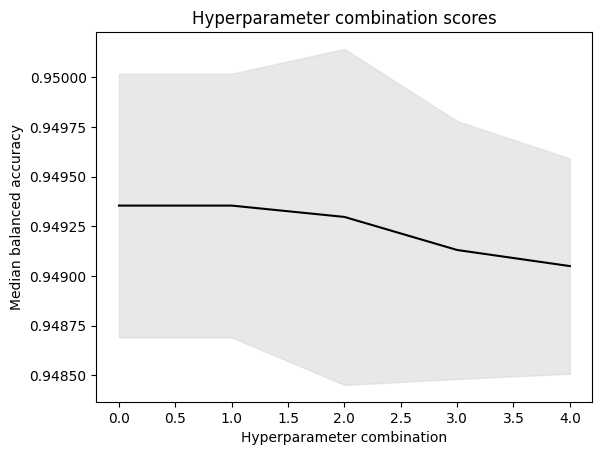

In [5]:
# Summarize each candidate by median score and fold-level uncertainty.
median_scores_df = pd.DataFrame({
    'median_score': [row['median'] for row in search_rows],
    '95% CI lower': [np.percentile(row['fold_scores'], 2.5) for row in search_rows],
    '95% CI upper': [np.percentile(row['fold_scores'], 97.5) for row in search_rows],
})

# Plot candidate rank (x-axis) versus median CV score with 95% fold interval.
plt.title('Hyperparameter combination scores')
plt.plot(list(range(len(median_scores_df))), median_scores_df['median_score'], color='black')
plt.fill_between(
    list(range(len(median_scores_df))),
    median_scores_df['95% CI lower'],
    median_scores_df['95% CI upper'],
    color='lightgray',
    alpha=0.5
)
plt.xlabel('Hyperparameter combination')
plt.ylabel('Median balanced accuracy')
plt.show()

## 4. Cross-validation performance estimate

In [6]:
if RUN_FULL_CV_ESTIMATE:

    # Re-score the selected candidate on all engineered folds.
    full_fold_scores = score_on_folds(
        engineered_folds,
        best_params,
        use_sampling=USE_CV_SAMPLING,
        train_sample_fraction=CV_TRAIN_SAMPLE_FRAC,
        validation_sample_fraction=CV_VALIDATION_SAMPLE_FRAC,
    )

    # Store both metric summary and run settings for reproducibility.
    cv_results = {
        'params': best_params,
        'fold_scores': full_fold_scores,
        'mean': float(np.mean(full_fold_scores)),
        'median': float(np.median(full_fold_scores)),
        'std': float(np.std(full_fold_scores)),
        'used_sampling': USE_CV_SAMPLING,
        'train_sample_fraction': CV_TRAIN_SAMPLE_FRAC,
        'validation_sample_fraction': CV_VALIDATION_SAMPLE_FRAC,
    }

    with open(CROSS_VALIDATION_SCORES, 'wb') as handle:
        pickle.dump(cv_results, handle)

else:
    with open(CROSS_VALIDATION_SCORES, 'rb') as handle:
        cv_results = pickle.load(handle)

# Print a compact report for quick notebook comparisons.
print('Cross-validation summary')
print(f"Mean balanced accuracy:   {cv_results['mean']:.4f}")
print(f"Median balanced accuracy: {cv_results['median']:.4f}")
print(f"Std balanced accuracy:    {cv_results['std']:.4f}")
print(f"Used sampling:            {cv_results.get('used_sampling', False)}")

if cv_results.get('used_sampling', False):
    print(f"Train sample fraction:    {cv_results.get('train_sample_fraction', 1.0):.2f}")
    print(f"Validation sample fraction: {cv_results.get('validation_sample_fraction', 1.0):.2f}")

Cross-validation summary
Mean balanced accuracy:   0.9494
Median balanced accuracy: 0.9494
Std balanced accuracy:    0.0011
Used sampling:            True
Train sample fraction:    0.70
Validation sample fraction: 0.70


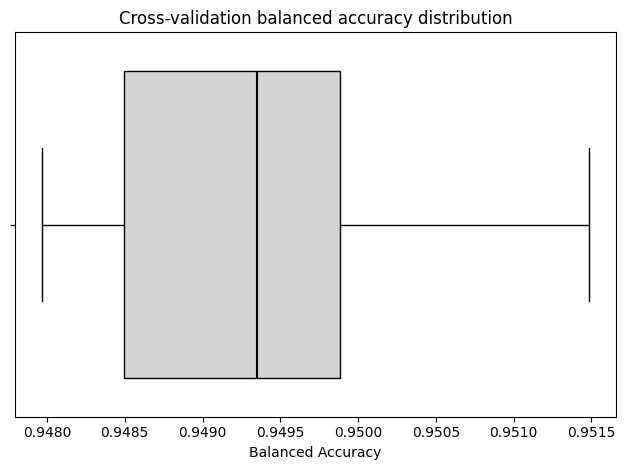

In [8]:
plt.title('Cross-validation balanced accuracy distribution')
sns.boxplot(
    x=full_fold_scores,
    color='lightgray',
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)
plt.xlabel('Balanced Accuracy')
plt.tight_layout()
plt.show()

## 5. Train final model and generate submission

In [7]:
# Train one final model on the full engineered training artifact.
final_model = build_model(best_params, seed=315)
final_model.fit(train_df.drop('health_condition', axis=1), train_df['health_condition'])

# Predict on engineered test features (exclude id from model input).
test_features = test_df.drop('id', axis=1)
test_predictions = final_model.predict(test_features)

# Convert encoded predictions back to competition label strings.
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'health_condition': label_encoder.inverse_transform(test_predictions),
})

# Save submission in the standard project location.
submission_df.to_csv(FINAL_SUBMISSION_FILE, index=False)

print(f'Saved submission to {FINAL_SUBMISSION_FILE}')
print(submission_df['health_condition'].value_counts())

submission_df.head()

Saved submission to ../data/submission_09-gradient-boosting-engineered.csv
health_condition
at-risk      239357
unhealthy     34527
fit           21869
Name: count, dtype: int64


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
